<a href="https://colab.research.google.com/github/Shivssv1012/Deep-Learning-/blob/main/keras_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv('/content/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.corr()['Outcome']

,Outcome
Pregnancies,0.221898
Glucose,0.466581
BloodPressure,0.065068
SkinThickness,0.074752
Insulin,0.130548
BMI,0.292695
DiabetesPedigreeFunction,0.173844
Age,0.238356
Outcome,1.000000


In [6]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [9]:
X=scaler.fit_transform(X)

In [10]:
X.shape

(768, 8)

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [110]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout

In [13]:
model=Sequential()

In [14]:
model.add(Dense(32, activation='relu', input_dim=8))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy',metrics=['accuracy'] )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
history=model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5505 - loss: 0.6943 - val_accuracy: 0.6494 - val_loss: 0.6553
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6938 - loss: 0.6195 - val_accuracy: 0.7403 - val_loss: 0.5902
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7215 - loss: 0.5700 - val_accuracy: 0.7857 - val_loss: 0.5442
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7378 - loss: 0.5383 - val_accuracy: 0.7727 - val_loss: 0.5193
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7557 - loss: 0.5155 - val_accuracy: 0.7662 - val_loss: 0.4983
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7655 - loss: 0.5011 - val_accuracy: 0.7727 - val_loss: 0.4840
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7557 - loss: 0.4900 - val_accuracy: 0.7857 - val_loss: 0.4762
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7687 - loss: 0.4812 - val_accuracy: 0.7857 - 

In [19]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.3 MB/s eta 0:00:00


In [20]:
#selecting optimal optimizer
import kerastuner as kt

/tmp/ipykernel_902/1409887377.py:2: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  import kerastuner as kt


In [21]:
#model building
def build_model(hp):
  model=Sequential()
  model.add(Dense(32, activation='relu', input_dim=8))
  model.add(Dense(16,activation='relu'))
  model.add(Dense(1,activation='sigmoid'))

  model.compile(optimizer=hp.Choice('optimizer',['adam', 'sgd', 'rmsprop','adadelta']),loss='binary_crossentropy', metrics=['accuracy'] )
  return model
  #or
  # optimizer=hp.Choice('optimizer',values= ['adam', 'sgd', 'rmsprop', 'adadelta'])
  # model.compile(optimizer=optimizer)

In [23]:
#tuner object
tuner=kt.RandomSearch(build_model, objective='val_accuracy', max_trials=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
tuner.search(X_train,y_train, epochs=5, validation_data=(X_test, y_test))

Trial 4 Complete [00h 00m 04s]
val_accuracy: 0.7337662577629089

Best val_accuracy So Far: 0.7337662577629089
Total elapsed time: 00h 01m 15s


In [27]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'sgd'}

In [28]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.fit(X_train,y_train, epochs=100, initial_epoch=6, validation_data=(X_test, y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7362 - loss: 0.5706 - val_accuracy: 0.7532 - val_loss: 0.5435
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7427 - loss: 0.5591 - val_accuracy: 0.7727 - val_loss: 0.5335
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7410 - loss: 0.5492 - val_accuracy: 0.7792 - val_loss: 0.5249
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7541 - loss: 0.5401 - val_accuracy: 0.8052 - val_loss: 0.5175
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7541 - loss: 0.5326 - val_accuracy: 0.7987 - val_loss: 0.5111
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7541 - loss: 0.5258 - val_accuracy: 0.8052 - val_loss: 0.5061
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7590 - loss: 0.5197 - val_accuracy: 0.8052 - val_loss: 0.5014
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7557 - loss: 0.5141 - val_accuracy: 0

In [63]:
#tuning to find the right no. of neurons per layer
def build_model(hp):
  model=Sequential()
  model.add(Dense(units=hp.Int('units_layer1', min_value=8, max_value=128,step=8), activation='relu', input_dim=8))
  model.add(Dense(units=hp.Int('units_layer2', min_value=8, max_value=128,step=8), activation='relu'))

  #or
  #units=hp.Int(min_value=8, max_value=128, step=8,activatio='relu', input_dim=8)
  #model.add(Dense(units=units))

  model.add(Dense(1,activation='sigmoid'))
  model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [64]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=5,
                      directory='mydir',
                      project_name='shiv1'
                      )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
tuner.search(X_train,y_train, epochs=5, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 03s]
val_accuracy: 0.7467532753944397

Best val_accuracy So Far: 0.7727272510528564
Total elapsed time: 00h 00m 15s


In [66]:
tuner.get_best_hyperparameters()[0].values

{'units_layer1': 32, 'units_layer2': 72}

In [68]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
model.fit(X_train, y_train, epochs=100, initial_epoch=6, validation_data=(X_test, y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7036 - loss: 0.6266 - val_accuracy: 0.7468 - val_loss: 0.6088
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7150 - loss: 0.6142 - val_accuracy: 0.7468 - val_loss: 0.5974
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7117 - loss: 0.6031 - val_accuracy: 0.7468 - val_loss: 0.5871
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7182 - loss: 0.5926 - val_accuracy: 0.7468 - val_loss: 0.5786
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7264 - loss: 0.5842 - val_accuracy: 0.7532 - val_loss: 0.5706
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7313 - loss: 0.5760 - val_accuracy: 0.7403 - val_loss: 0.5631
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7313 - loss: 0.5682 - val_accuracy: 0.7403 - val_loss: 0.5568
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7362 - loss: 0.5613 - val_accuracy: 0.74

In [72]:
#now finding no. of layers
def build_model(hp):
  model=Sequential()
  model.add(Dense(32, activation='relu',input_dim=8))
  for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
    model.add(Dense(32, activation='relu'))

  model.add(Dense(1,activation='sigmoid'))

  model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
  return model

In [74]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=3,
                      directory='mydir',
                      project_name='shiv2')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Trial 3 Complete [00h 00m 03s]
val_accuracy: 0.7207792401313782

Best val_accuracy So Far: 0.7207792401313782
Total elapsed time: 00h 00m 12s


In [76]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 1}

In [77]:
model=tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379 (5.39 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [79]:
history1=model.fit(X_train ,y_train,epochs=100, initial_epoch=6, validation_data=(X_test, y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7850 - loss: 0.4337 - val_accuracy: 0.8052 - val_loss: 0.4446
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7883 - loss: 0.4335 - val_accuracy: 0.7987 - val_loss: 0.4456
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7915 - loss: 0.4332 - val_accuracy: 0.8052 - val_loss: 0.4451
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7899 - loss: 0.4331 - val_accuracy: 0.8052 - val_loss: 0.4450
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7883 - loss: 0.4328 - val_accuracy: 0.8052 - val_loss: 0.4451
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7899 - loss: 0.4323 - val_accuracy: 0.8052 - val_loss: 0.4450
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7915 - loss: 0.4321 - val_accuracy: 0.8052 - val_loss: 0.4443
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7850 - loss: 0.4318 - val_accuracy: 0.

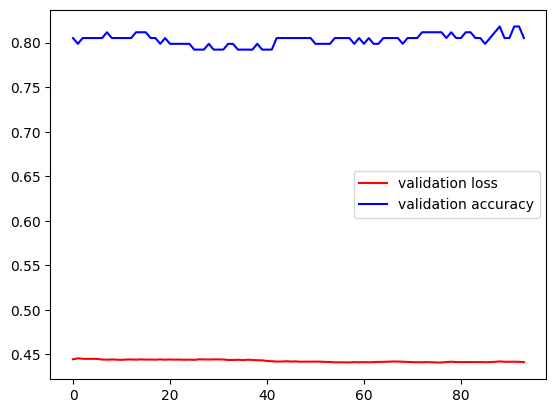

In [81]:
import matplotlib.pyplot as plt
plt.plot(history1.history['val_loss'], color='red', label='validation loss')
plt.plot(history1.history['val_accuracy'], color='blue', label='validation accuracy')
plt.legend()
plt.show()

In [111]:
def build_model(hp):
  model=Sequential()
  counter=0
  for i in range(hp.Int('num_layers', min_value=1,max_value=10)):
    if counter==0:
      model.add(Dense(hp.Int('units'+str(i), min_value=8, max_value=128, step=8),
                      activation=hp.Choice('activation'+str(i),values=['relu','sigmoid','tanh'])))
      model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    else:
      model.add(Dense(hp.Int('units'+str(i), min_value=8, max_value=128, step=8),
                      activation=hp.Choice('activation'+str(i), values=['relu','sigmoid','tanh'])))
      model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])))
    counter+=1
  model.add(Dense(1,activation='sigmoid'))
  model.compile(optimizer=hp.Choice('optimizer', values=['rmsprop','sgd','adam','adadelta']),
                loss='binary_crossentropy',
                metrics=['accuracy'])
  return model

In [112]:
tuner=kt.RandomSearch(build_model, objective='val_accuracy',
                      max_trials=3,
                      directory='mydir',
                      project_name='shiv7'
                      )

In [113]:
tuner.search(X_train, y_train, epochs=5, validation_data=(X_test,y_test))

Trial 3 Complete [00h 00m 04s]
val_accuracy: 0.6428571343421936

Best val_accuracy So Far: 0.798701286315918
Total elapsed time: 00h 00m 14s


In [114]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 1,
 'units0': 112,
 'activation0': 'relu',
 'dropout0': 0.9,
 'optimizer': 'adam'}

In [115]:
model=tuner.get_best_models()[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [116]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 112)            │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           113 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
model.fit(X_train,y_train, epochs=200, initial_epoch=5, validation_data=(X_test, y_test))

Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6482 - loss: 0.6526 - val_accuracy: 0.7922 - val_loss: 0.5428
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.6441 - val_accuracy: 0.7922 - val_loss: 0.5284
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6612 - loss: 0.6201 - val_accuracy: 0.7987 - val_loss: 0.5157
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6612 - loss: 0.6368 - val_accuracy: 0.7987 - val_loss: 0.5075
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7003 - loss: 0.5886 - val_accuracy: 0.7987 - val_loss: 0.5017
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6808 - loss: 0.6056 - val_accuracy: 0.7987 - val_loss: 0.4965
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7020 - loss: 0.5790 - val_accuracy: 0.7987 - val_loss: 0.4935
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6808 - loss: 0.5830 - val_accuracy: 0